# Notebook Objectives

This notebook computes neural values for one session. For all sessions, we do the same in ```neural_value_RUN_all_sessions.py```, results shown in ```neural_value_all_sessions.ipynb```.

Results include:
* Neural value vs. behavior (last 3 outcomes, behavioral value, long history, etc)
* Change in neural value, etc

---
# Setup


In [10]:
from neural_value_helpers import *
from popy.config import COLORS

---
# Section 1: Get data, extract neural value

In [2]:
monkey, session, subregion = 'ka', '010720', 'MCC'

t_interest_value = [2, 3.5]
build_data = False

all_figs = []

In [3]:
floc = 'data/{}_{}_neural.nc'.format(monkey, session)

if not build_data: 
    neural_dataset_all = xr.open_dataset(floc)
else:
    neural_dataset_all = load_data_custom(monkey, session, n_extra_trials=(-1, 0), sr=10)
    # save the dataset
    neural_dataset_all.to_netcdf(floc)

neural_dataset = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
neural_dataset

<xarray.Dataset>
Dimensions:           (unit: 11, trial_id: 433, time: 150)
Coordinates: (12/27)
  * unit              (unit) object 'MCC_05_01' 'MCC_06_01' ... 'MCC_16_02'
    unit_id_original  (unit) int64 ...
    channel           (unit) int64 ...
    monkey            (unit) object ...
    session           (unit) object ...
    area              (unit) object ...
    ...                ...
    R_4               (trial_id) float64 ...
    R_5               (trial_id) float64 ...
    R_6               (trial_id) float64 ...
    R_7               (trial_id) float64 ...
    R_8               (trial_id) float64 ...
    fb_sequence       (trial_id) float64 ...
Data variables:
    firing_rates      (trial_id, unit, time) float64 ...
Attributes:
    bin_size:  0.1

## Projection to value subspace

In [4]:
#results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
decodability_matrix, data_projected = time_resolved_decoder_all_time(neural_dataset, target='R_1', across_time=False)

# get neural value for the current trial and the previous one
data_projected = add_neural_value_coord(data_projected, t_interest=t_interest_value)

In [5]:
# mean trajectories per fb sequence

def convert_trajectorie_format(data_projected):
    """ Convert the data_projected xarray to a format where each fb_sequence is averaged across trials."""
    data_projected_mean = []
    for fb_seq in np.unique(data_projected.fb_sequence.values):
        data_projected_temp = data_projected.sel(trial_id=data_projected.fb_sequence==fb_seq)
        if len(data_projected_temp) > 0:
            data_projected_temp = data_projected_temp.mean(dim='trial_id')
            data_projected_temp = data_projected_temp.assign_coords(fb_sequence=fb_seq)
            data_projected_mean.append(data_projected_temp)

    data_projected_mean = xr.concat(data_projected_mean, dim='fb_sequence')
    # dd new dimension (not coordinate)

    return data_projected_mean

In [ ]:
x1 = convert_trajectorie_format(data_projected)
x2 = convert_trajectorie_format(data_projected)

x1 = x1.expand_dims(session=[f'{monkey}_{session}_{subregion}'])
x2 = x2.expand_dims(session=[f'{monkey}_{session}_{subregion}'])

# concatenate the two datasets
x3 = xr.concat([x1, x2], dim='session')
# convert to dataset
x3 = x3.to_dataset(
x3

AttributeError: 'DataArray' object has no attribute 'open_dataarray'

<xarray.DataArray (session: 169, fb_sequence: 8, time: 150)>
[202800 values with dtype=float64]
Coordinates:
  * session       (session) object 'ka_230720_MCC' ... 'po_280421_dLPFC'
  * time          (time) float64 -7.5 -7.4 -7.3 -7.2 -7.1 ... 7.1 7.2 7.3 7.4
    epoch         (time) float64 ...
    decodability  (session, time) float64 ...
  * fb_sequence   (fb_sequence) float64 0.0 1.0 2.0 3.0 4.0 5.0 6.0 7.0

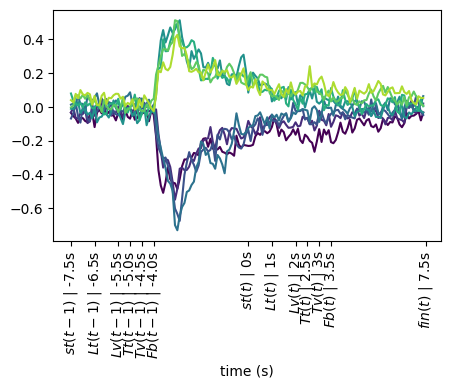

In [32]:
# open fike
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
floc = '/Users/zsombi/ZSOMBI/SBRI/PoPy/notebooks/population_decoding/results/neural_values_across_time copy/across_time_decodability_matrix.nc'
decodability_matrix = xr.open_dataarray(floc)
floc = '/Users/zsombi/ZSOMBI/SBRI/PoPy/notebooks/population_decoding/results/neural_values_across_time copy/trajectories.nc'
trajectories = xr.open_dataarray(floc)

fig, ax = plt.subplots(figsize=(5, 3))
cmap = plt.get_cmap('viridis')

# where the session field ends with MCC
trajectories_mcc = trajectories.sel(session=(trajectories.session.str.endswith('LPFC')) & (trajectories.session.str.startswith('po')))
for fb_seq in np.unique(trajectories.fb_sequence.values):
    data = trajectories_mcc.sel(fb_sequence=fb_seq).mean(dim='session').values
    ax.plot(trajectories_mcc.time, data, label=fb_seq, color=cmap(fb_seq / len(np.unique(trajectories.fb_sequence.values))))

plot_keypoints(ax, (-1, 0))
'''ax.set_xlim(0, 6)
ax.set_ylim(-.5, .5)'''
trajectories

TypeError: Invalid shape (1, 150, 150) for image data

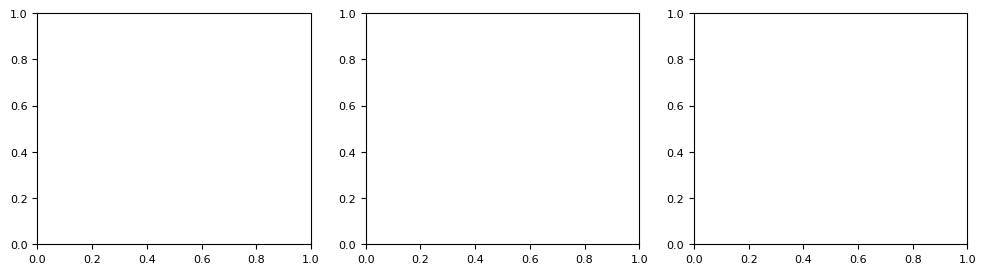

In [ ]:
# Plot the results
fig, axes = plot_across_time_decodability(projected_data=data_projected, decodability_matrix=decodability_matrix)

plt.suptitle('{} {} {}'.format(monkey, session, subregion), fontsize=10)

all_figs.append(fig)

In [ ]:
fig, ax = plot_projected_data(data_projected, t_interest_value, n_extra_trials=(-1, 0), xlim=[-5, 5], paper_format=True)
# hide legend
plt.suptitle(f'{monkey} {session} {subregion}, t_eval = {t_interest_value}s', fontsize=10)

all_figs.append(fig)

# save figure
fig.savefig(f'figs/{monkey}_{session}_{subregion}_neural_value.svg', bbox_inches='tight', transparent=True)

In [ ]:
# render Vt coord
data_projected = data_projected.rename({'V_t': 'V_t_prev___'})
data_projected

## Extract neural value

In [ ]:
behav_new = data_projected.mean('time').coords.to_dataset().to_dataframe().reset_index()

behav_new['monkey'] = monkey
behav_new['session'] = session
#behav_new['area'] = neural_dataset.area
behav_new['subregion'] = subregion

# put monkey, session, subregion in the front
behav_new = behav_new[['monkey', 'session', 'subregion'] +
                       [c for c in behav_new.columns if c not in ['monkey', 'session', 'subregion']]]
behav_new = behav_new.dropna()
behav_new


In [ ]:
# save behav_new to csv
behav_new.to_csv(f'data/{monkey}_{session}_{subregion}_neural_value.csv', index=False)

---
# Section 2: Analysis of the neural value representation

## Green red plot: Value evolves according to feedback

In [ ]:
fig, ax = plot_projection_timepoint(behav_new, paper_format=False, ylim=None, show_datapoints=True)

plt.suptitle(f'{monkey} {session} {subregion}, t_fit = {t_interest_value} s', fontsize=10)

all_figs.append(fig)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


# Data setup
weights_all = []
for monkey in behav_new.monkey.unique():
    for subregion in behav_new.subregion.unique():
        behav_temp = behav_new.loc[(behav_new.monkey == monkey) & (behav_new.subregion == subregion)]

        for session in behav_temp.session.unique():
            behav = behav_temp.loc[behav_temp.session == session].copy()

            y = behav.V_t.values
            X = np.array([behav[f'R_{i}'].values for i in range(1, 9)]).T

            # Add intercept for statsmodels
            X_sm = sm.add_constant(X)
            model = sm.OLS(y, X_sm)
            results = model.fit()

            # Extract weights and p-values (skip intercept)
            weights = results.params[1:]
            pvals = results.pvalues[1:]
            
            res_temp = {f'R_{i}': results.params[i] for i in range(1, len(weights) + 1)}
            res_temp['monkey'] = monkey
            res_temp['session'] = session
            res_temp['subregion'] = subregion
            weights_all.append(res_temp)

weights_all = pd.DataFrame(weights_all)
weights_all

In [ ]:
# Plot the weights
weights_all = simple_glm_weights(behav_new)
fig, axs = plot_simple_glm_weights(weights_all)

plt.suptitle(f'{monkey} {session} {subregion} - Simple GLM weights', fontsize=10)

all_figs.append(fig)

In [ ]:
n_perms = 100

cpds_all = process_single_session(behav_new)
cpds_all = add_corrected_pvals(cpds_all)
cpds_all

In [ ]:
fig, axs = plot_prop_signif_sessions(cpds_all)



In [ ]:
null = create_permutation_null(behav_new, n_perms=100)

fig, axs = plot_cpds_history_neural_value(cpds_all, null)

plt.suptitle(f'{monkey} {session} {subregion} - CPDs', fontsize=10)

all_figs.append(fig)


---
# Save figs

In [ ]:
'''save_figures_split_layout(all_figs, filename="combined_figures_row.pdf", figsize=(20, 5), title=f'{monkey} {session} {subregion}')'''